# Step 06. The figure: cohort A at k = 2, 3, 4, 5

Patients × proteins, both axes grouped, so a group of patients reads as a block rather than as
two dendrograms glued to the sides of a heatmap.

**What this figure is for.** Step 05 found that no patient partition survives cross-validation at
any k. This draws the partitions anyway, at four values of k, so that conclusion can be *seen*
instead of taken on trust. If there were endotypes, raising k would subdivide blocks into smaller
blocks. Watch what it does instead.

In [1]:
suppressMessages({library(ComplexHeatmap); library(circlize); library(grid)})
set.seed(42)
source("../src/paths.R")
w   <- readRDS(art("wgcna_A.rds")); ee <- readRDS(art("eigengenes_A.rds"))
sig <- readRDS(art("sig_modules_A.rds")); en <- readRDS(art("endotypes_A.rds"))
X <- w$X; m <- w$meta; mods <- w$mods; ifn <- en$ifn
cat(sprintf("cohort %s: %d patients, %d proteins, %d associated modules; interferon = %s\n",
            w$cohort, nrow(X), ncol(X), length(sig), ifn))

cohort A: 87 patients, 7288 proteins, 12 associated modules; interferon = ivory


## Three choices behind the picture

**Cap each module's contribution.** Twelve proteins per module, ranked by module membership.
Without a cap, `blue`'s 1,213 proteins would occupy the whole width and a 14-protein interferon
module would be invisible.

**Scale per protein, across patients. One axis only.** Z-scoring patients as well forces each row to
sum to zero and manufactures anticorrelation between proteins.

**ward.D2 within each block.** Ward minimises the increase in within-cluster variance at each merge,
which produces tight rectangles rather than the chained strands single-linkage gives.

The columns are identical in all four panels, same proteins, same order, same module blocks.
Only the row grouping changes with k, so the panels are directly comparable.

In [2]:
CAP <- 12
sel <- unlist(lapply(sig, function(md0) {
  g <- colnames(X)[mods == md0]
  g[order(-abs(cor(X[, g, drop = FALSE], ee$ME[[paste0("ME", md0)]])))][1:min(CAP, length(g))]
}))
ord  <- sig[order(sapply(sig, function(k) sum(mods == k)))]   # small modules first
modf <- factor(mods[match(sel, colnames(X))], levels = ord)
Z    <- scale(as.matrix(X[, sel]))
ann  <- m[, c("Disease_activity","SLEDAI_2K","C3_level","Sm_status","Ro_60_status","Duration_years")]
# Build the annotation ONCE and reuse the object in every panel. A fresh
# rowAnnotation() per panel gets its own colour mapping, so "Disease_activity"
# would be a different colour in each -- and the panels are meant to be compared.
HA <- rowAnnotation(df = ann, annotation_name_gp = gpar(fontsize = 6),
                    show_legend = FALSE)
sprintf("%d modules, %d proteins (capped at %d per module)", length(sig), length(sel), CAP)

[1] "12 modules, 140 proteins (capped at 12 per module)"

In [3]:
KS <- 2:5
CAPTION <- list()
S   <- en$S                                   # the space step 05 clustered in
sup <- en$support[en$support$space == en$space, ]

panel <- function(K) {
  set.seed(42)
  cl  <- factor(paste0("E", kmeans(S, K, nstart = 50)$cluster))
  row <- sup[sup$k == K, ]
  CAPTION[[as.character(K)]] <<- sprintf("cohort %s, k = %d  --  sizes %s, prediction strength %.2f (%s)",
                                         w$cohort, K, row$sizes, row$pred_strength,
                                         if (row$passes) "PASS" else "FAIL")
  Heatmap(Z, name = "z-score",
    col = colorRamp2(c(-2, 0, 2), c("#2166AC", "white", "#B2182B")),
    row_split = cl, column_split = modf,
    cluster_rows = TRUE, cluster_row_slices = FALSE, cluster_columns = TRUE,
    clustering_method_rows = "ward.D2", clustering_method_columns = "ward.D2",
    show_row_dend = TRUE, row_dend_width = unit(18, "mm"), show_row_names = FALSE,
    show_column_dend = FALSE,
    column_names_side = "bottom", column_names_gp = gpar(fontsize = 4),
    column_title_gp = gpar(fontsize = 6), column_title_rot = 90,
    row_title_gp = gpar(fontsize = 9),
    left_annotation = HA,
    heatmap_legend_param = list(labels_gp = gpar(fontsize = 7),
                                title_gp  = gpar(fontsize = 8)))
  # NOTE: no column_title here. With column_split set, Heatmap()'s column_title
  # becomes the PER-SLICE title -- passing one long string there prints it
  # rotated across the top and costs you the module names. The caption goes on
  # draw() instead. (The same trap is documented in src/final_matrix.R.)
}
hts <- lapply(KS, panel)
names(hts) <- paste0("k", KS)
length(hts)

[1] 4

In [4]:
# One 2x2 figure. draw(newpage = FALSE) lets several heatmaps share a device.
png(art("fig06_endotypes_k2to5_%s.png", w$cohort), width = 3400, height = 2600, res = 150)
grid.newpage()
pushViewport(viewport(layout = grid.layout(2, 2)))
for (i in seq_along(hts)) {
  pushViewport(viewport(layout.pos.row = (i - 1) %/% 2 + 1,
                        layout.pos.col = (i - 1) %%  2 + 1))
  draw(hts[[i]], newpage = FALSE,
       column_title = CAPTION[[as.character(KS[i])]],
       column_title_gp = gpar(fontsize = 11, fontface = "bold"))
  popViewport()
}
popViewport()
invisible(dev.off())
cat("wrote", art("fig06_endotypes_k2to5_%s.png", w$cohort), "\n")

wrote /Users/adeslatt/Scitechcon Dropbox/Anne DeslattesMays/projects/endotypes-proteomics/data/run_artifacts/fig06_endotypes_k2to5_A.png 


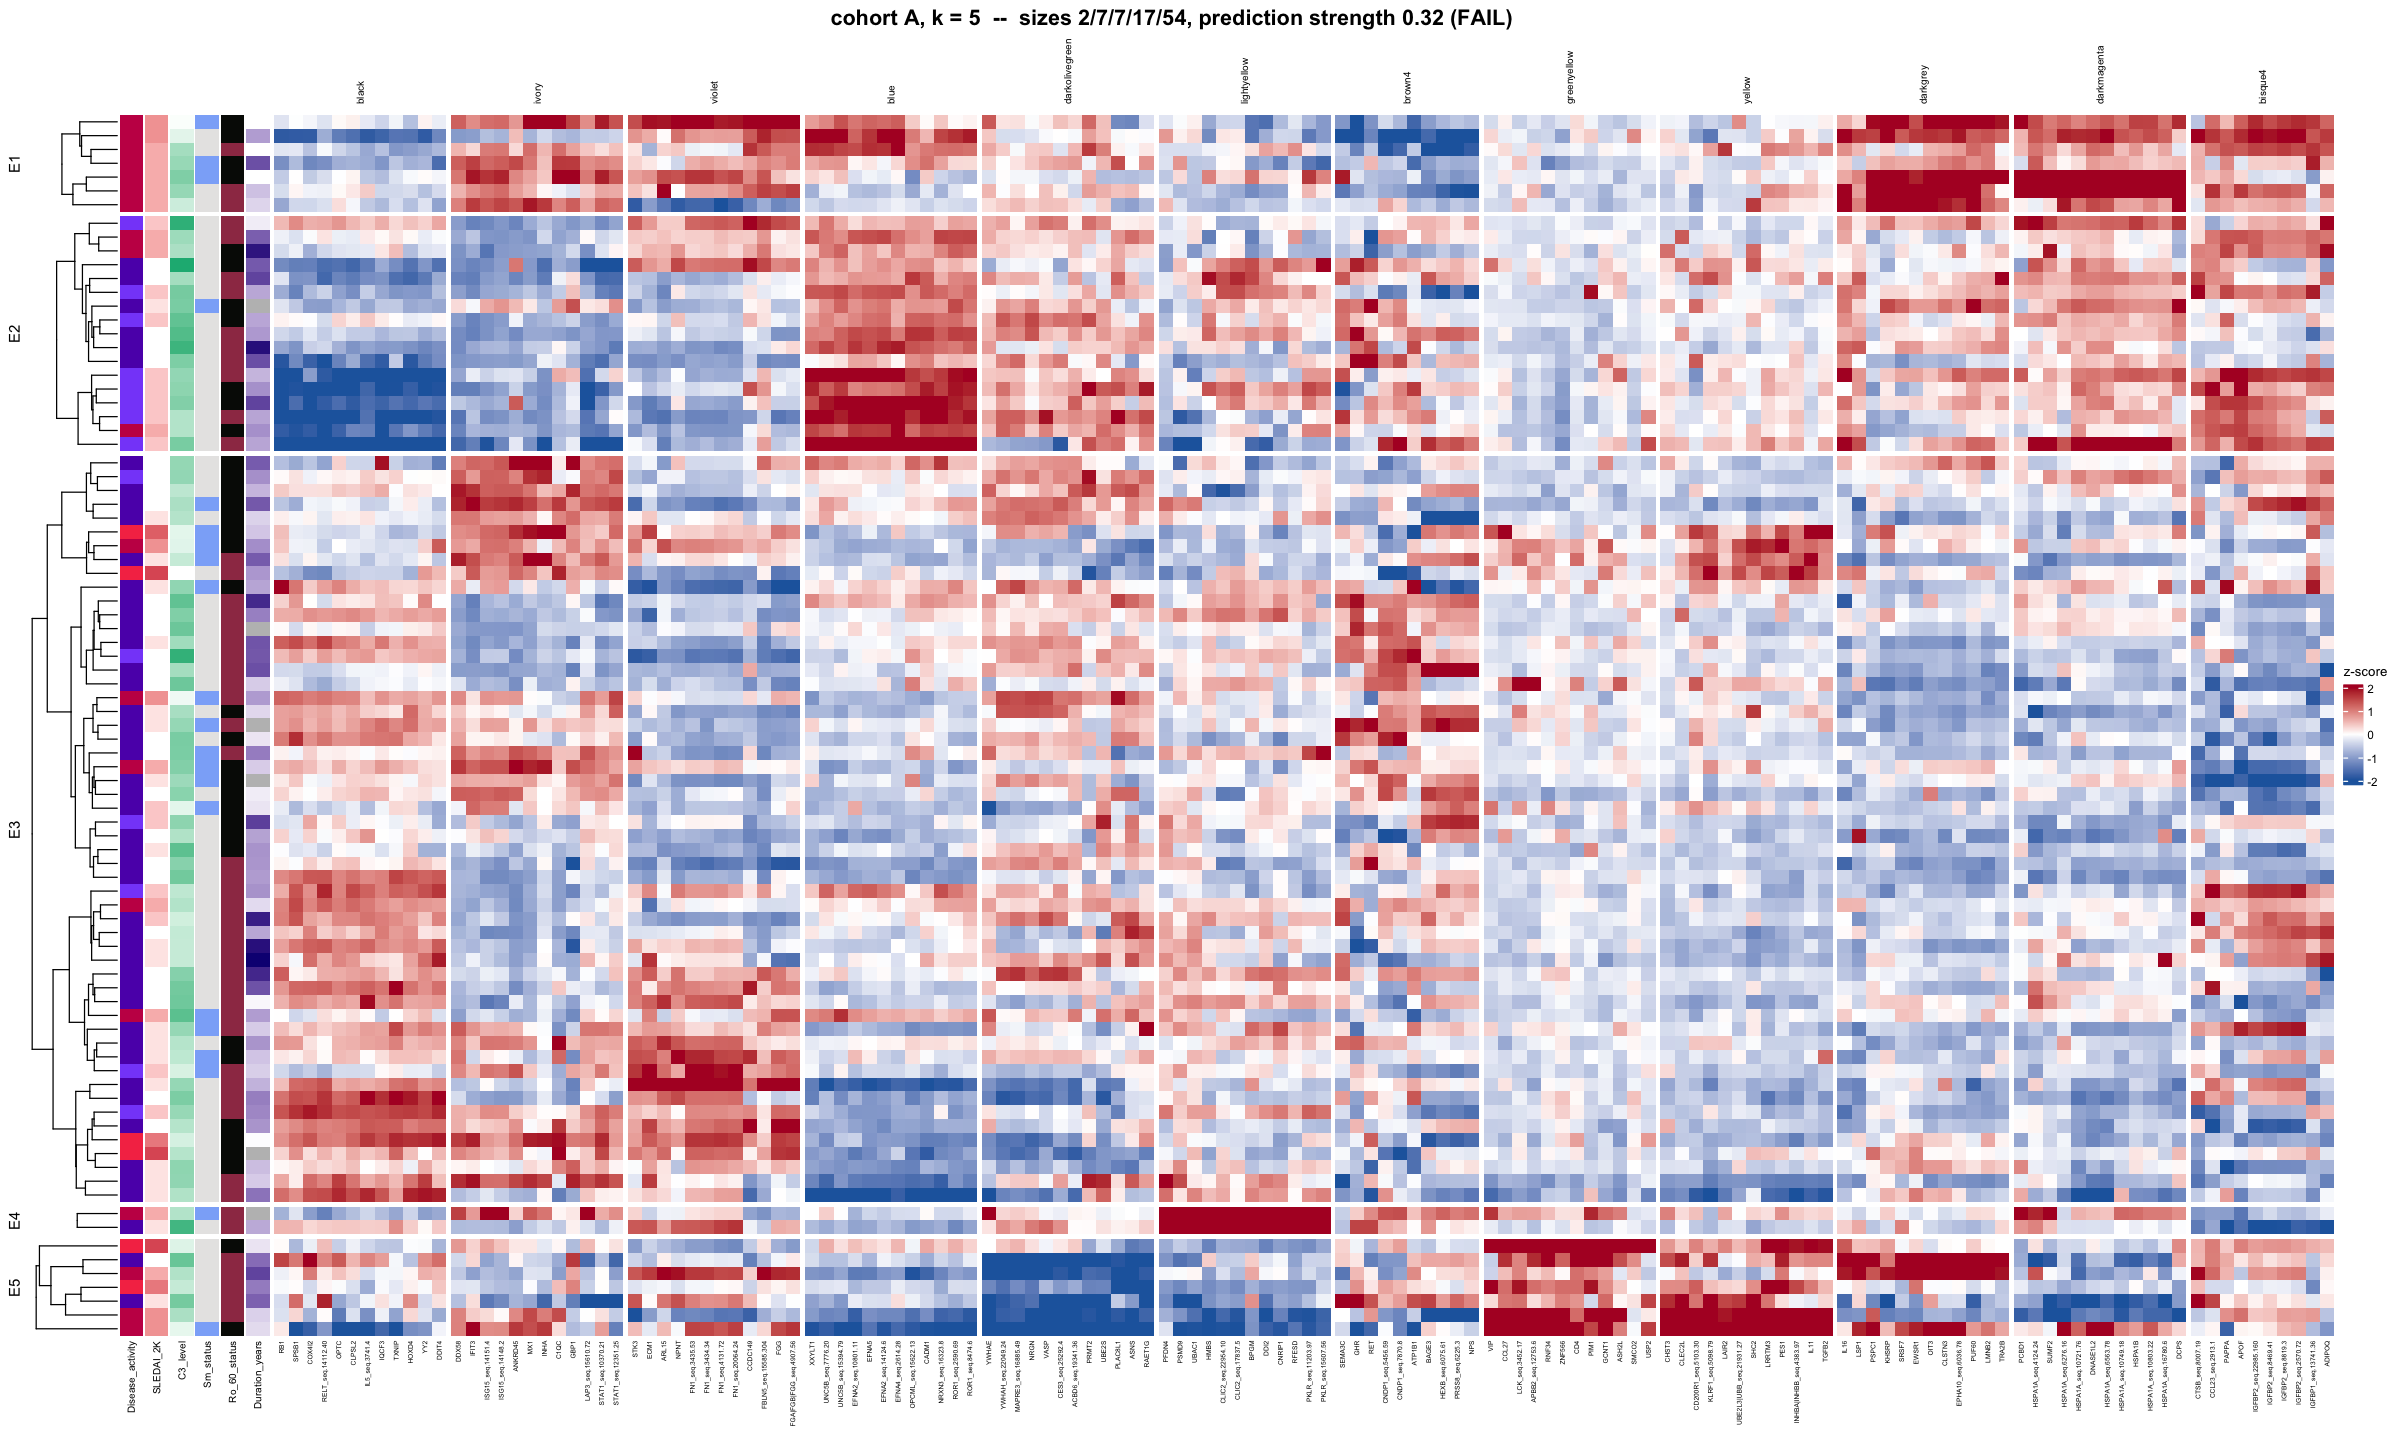

In [5]:
# The same four panels inline, one at a time, at readable size.
options(repr.plot.width = 20, repr.plot.height = 12)
for (i in seq_along(hts))
  draw(hts[[i]], column_title = CAPTION[[as.character(KS[i])]],
       column_title_gp = gpar(fontsize = 13, fontface = "bold"))

## Reading the figure

**Look at the row blocks as k rises.** Going from k = 2 to k = 5 the partition does not carve the
two blocks into four or five smaller coherent blocks. It peels off 7 patients, then 2, then 2
more, the group of 54–59 stays put and everything else fragments around its edge. That is what
"prediction strength falls monotonically" looks like as a picture: each new cluster is an outlier
shaving, not a new mechanism, and it does not survive being shown new patients.

**Look at the interferon column block**, `ivory` in this fit, 14 proteins and narrow. Its high rows are
a scattered subset cutting across *every* partition rather than filling any one group. Those are the
interferon-high patients, and no value of k isolates them, consistent with step 05's finding that
the interferon axis is orthogonal to whatever k-means is following, and with step 08, where the same
module cleanly separates healthy volunteers from systemic lupus erythematosus (SLE) at −1.02 SD.

**The module the evidence points at is the one no partition here captures.** That is the argument
for clustering on the interferon module alone, and for step 07's question: whether these modules
mean the same thing at another site at all.

## Where this was run

Rendered notebooks are committed, so each records the machine, the R and the
package versions that produced its output.


In [ ]:
run_provenance()